In [1]:
# Importing important libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import TimeseriesGenerator


In [2]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Wheat Futures Historical Data.csv'].decode('utf-8')))

Saving US Wheat Futures Historical Data.csv to US Wheat Futures Historical Data (2).csv


In [3]:
# Changing the format of the 'Date'column from object to datetime format
data['Date']=pd.to_datetime(data['Date'], infer_datetime_format=True)

In [4]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [5]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [6]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date     0
Price    0
Open     0
High     0
Low      0
Vol.     0
dtype: int64


<ipython-input-6-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1087 non-null   datetime64[ns]
 1   Price   1087 non-null   float64       
 2   Open    1087 non-null   float64       
 3   High    1087 non-null   float64       
 4   Low     1087 non-null   float64       
 5   Vol.    1087 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 51.1 KB


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

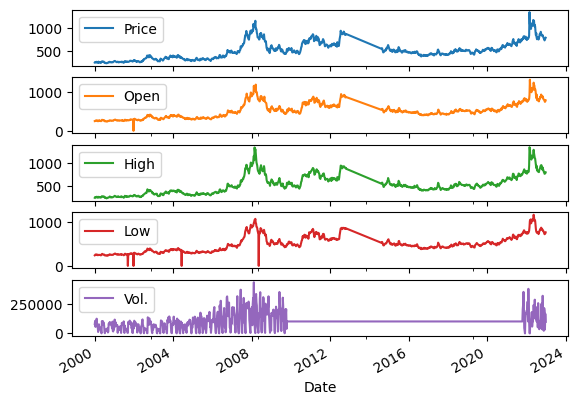

In [8]:
# Checking the correlation of each attribute with the date column
data.set_index('Date')[['Price','Open','High','Low', 'Vol.']].plot(subplots=True)

In [9]:
# Created a new dataframe which has all the columns
data_input=data[["Price",'Open','High','Low','Vol.']]
data_input

,Price,Open,High,Low,Vol.
0,792.00,781.25,799.00,765.50,97480.0
1,776.00,755.00,778.00,738.75,165670.0
2,753.50,742.50,772.00,737.60,32610.0
3,734.25,763.25,768.00,723.50,189690.0
4,761.00,793.25,799.25,755.75,213750.0
...,...,...,...,...,...
1082,257.00,258.25,260.00,249.00,75080.0
1083,259.75,265.50,269.00,256.50,89300.0
1084,264.25,261.50,267.00,261.00,55090.0
1085,265.00,251.25,267.75,248.75,105880.0


In [10]:
data_input.describe()

,Price,Open,High,Low,Vol.
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,510.476559,510.985216,529.382631,492.447792,100985.661376
std,192.748542,194.404552,205.563651,184.894417,57839.571027
min,236.750000,0.000000,239.750000,0.000000,120.000000
25%,356.500000,355.250000,366.500000,344.500000,79630.000000
50%,486.130000,486.380000,501.000000,471.250000,100985.661376
75%,611.750000,611.440000,634.575000,592.190000,100985.661376
max,1348.000000,1311.250000,1340.000000,1168.000000,431570.000000


In [11]:
# Standardisation of the dataset to have a standard mean so that the gradience converges faster
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_input)
data_scaled

array([[0.49966254, 0.59580553, 0.50829357, 0.65539384, 0.22565767],
       [0.48526434, 0.57578646, 0.489207  , 0.63249144, 0.38370611],
       [0.46501687, 0.56625357, 0.48375369, 0.63150685, 0.07530421],
       ...,
       [0.02474691, 0.19942803, 0.0247671 , 0.2234589 , 0.12740758],
       [0.02542182, 0.19161106, 0.02544876, 0.21297089, 0.2451269 ],
       [0.01349831, 0.18989514, 0.01113383, 0.20633562, 0.18389153]])

In [12]:
# Extracting the target variable 
features=data_scaled #attributes include all the columns including the target
target=data_scaled[:,0] #target only the first column = price

In [13]:
# Taking two weeks data points to predict the third, hence length=2. 
TimeseriesGenerator(features, target, length=2, sampling_rate=1, batch_size=1)[0]

(array([[[0.49966254, 0.59580553, 0.50829357, 0.65539384, 0.22565767],
         [0.48526434, 0.57578646, 0.489207  , 0.63249144, 0.38370611]]]),
 array([0.46501687]))

In [14]:
# Splitting the dataset in 98% train and 2% test dataset. 
# Shuffle=False because its a time series data
x_train, x_test, y_train, y_test= train_test_split(features, target, test_size=0.02, random_state=42, shuffle=False)

In [15]:
x_train.shape, x_test.shape

((1065, 5), (22, 5))

In [16]:
# Define TimeSeries Generator
win_length=4 #weekly dataset, so one month we have 4 datapoints
batch_size=32
num_features=5
train_generator= TimeseriesGenerator(x_train, y_train, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator= TimeseriesGenerator(x_test, y_test, length=win_length, sampling_rate=1, batch_size=batch_size)

In [17]:
train_generator[0] #32 observation cause of batch_size and each having window length of 4

(array([[[0.49966254, 0.59580553, 0.50829357, 0.65539384, 0.22565767],
         [0.48526434, 0.57578646, 0.489207  , 0.63249144, 0.38370611],
         [0.46501687, 0.56625357, 0.48375369, 0.63150685, 0.07530421],
         [0.44769404, 0.58207817, 0.48011815, 0.61943493, 0.43937884]],
 
        [[0.48526434, 0.57578646, 0.489207  , 0.63249144, 0.38370611],
         [0.46501687, 0.56625357, 0.48375369, 0.63150685, 0.07530421],
         [0.44769404, 0.58207817, 0.48011815, 0.61943493, 0.43937884],
         [0.47176603, 0.6049571 , 0.50852079, 0.64704623, 0.49514428]],
 
        [[0.46501687, 0.56625357, 0.48375369, 0.63150685, 0.07530421],
         [0.44769404, 0.58207817, 0.48011815, 0.61943493, 0.43937884],
         [0.47176603, 0.6049571 , 0.50852079, 0.64704623, 0.49514428],
         [0.4848144 , 0.61048618, 0.51715519, 0.66010274, 0.0518716 ]],
 
        [[0.44769404, 0.58207817, 0.48011815, 0.61943493, 0.43937884],
         [0.47176603, 0.6049571 , 0.50852079, 0.64704623, 0.49514428

In [18]:
# LSTM model architecture
model=tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(128, input_shape=(win_length, num_features), return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5)) #LeakyReLU activation function
model.add(tf.keras.layers.LSTM(128, return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.LSTM(128, return_sequences=False))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(1))

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 128)            68608     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 4, 128)            131584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 4, 128)            0         
                                                                 
 dropout (Dropout)           (None, 4, 128)            0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [20]:
# Defining the model
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, mode='min')

model.compile(loss=tf.losses.MeanSquaredError(), optimizer=tf.optimizers.Adam(), metrics=[tf.metrics.MeanAbsoluteError()])

history=model.fit_generator(train_generator, epochs=50, validation_data=test_generator, shuffle=False, callbacks=[early_stopping])

Epoch 1/50


<ipython-input-20-a45389fa3556>:6: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history=model.fit_generator(train_generator, epochs=50, validation_data=test_generator, shuffle=False, callbacks=[early_stopping])


34/34 [==============================] - 9s 72ms/step - loss: 0.0341 - mean_absolute_error: 0.1284 - val_loss: 6.8394e-04 - val_mean_absolute_error: 0.0250
Epoch 2/50
34/34 [==============================] - 2s 53ms/step - loss: 0.0192 - mean_absolute_error: 0.0944 - val_loss: 0.0014 - val_mean_absolute_error: 0.0371
Epoch 3/50
34/34 [==============================] - 1s 39ms/step - loss: 0.0076 - mean_absolute_error: 0.0634 - val_loss: 0.0014 - val_mean_absolute_error: 0.0357


In [21]:
# Checking on models on the test part
model.evaluate_generator(test_generator)

<ipython-input-21-fb2167925083>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  model.evaluate_generator(test_generator)


[0.0014030663296580315, 0.03571575507521629]

In [22]:
predictions=model.predict_generator(test_generator)

<ipython-input-22-6ca49477046f>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions=model.predict_generator(test_generator)


In [23]:
# Test data had 1000 datapoints and 4 win_length hence the prediction shape is 996 
predictions.shape[0]

18

In [24]:
predictions

array([[0.06973197],
       [0.06902245],
       [0.0624334 ],
       [0.05372356],
       [0.04737616],
       [0.04525715],
       [0.04964022],
       [0.05187305],
       [0.05351913],
       [0.05313575],
       [0.05258757],
       [0.0511996 ],
       [0.0461079 ],
       [0.0490997 ],
       [0.05508226],
       [0.05843568],
       [0.05622   ],
       [0.05364618]], dtype=float32)

In [25]:
x_test, y_test

(array([[0.03104612, 0.2135367 , 0.03658259, 0.22880993, 0.17589524],
        [0.03959505, 0.21010486, 0.04067257, 0.23416096, 0.18416966],
        [0.03554556, 0.21544328, 0.04158146, 0.23202055, 0.24063043],
        [0.03082115, 0.19752145, 0.0302204 , 0.22003425, 0.00164561],
        [0.02249719, 0.18951382, 0.02340377, 0.20804795, 0.02535636],
        [0.00494938, 0.18913251, 0.01386049, 0.20590753, 0.11468305],
        [0.0128234 , 0.19523356, 0.01681436, 0.21275685, 0.06642716],
        [0.01709786, 0.19656816, 0.01931379, 0.21532534, 0.08596593],
        [0.01957255, 0.20038132, 0.0247671 , 0.2151113 , 0.10098505],
        [0.02294713, 0.19370829, 0.021586  , 0.21275685, 0.12233167],
        [0.0143982 , 0.20400381, 0.0259032 , 0.21575342, 0.1784216 ],
        [0.03194601, 0.19256435, 0.0302204 , 0.21575342, 0.09688261],
        [0.01192351, 0.18798856, 0.01522381, 0.2104024 , 0.02823039],
        [0.00967379, 0.18836988, 0.01204272, 0.20890411, 0.11062696],
        [0.01012373,

In [26]:
# Creating a dataframe from the x_test which include the variables accept the 1st column
x_test[:,1][win_length:]

array([0.18951382, 0.18913251, 0.19523356, 0.19656816, 0.20038132,
       0.19370829, 0.20400381, 0.19256435, 0.18798856, 0.18836988,
       0.20152526, 0.20514776, 0.19752145, 0.19694948, 0.20247855,
       0.19942803, 0.19161106, 0.18989514])

In [27]:
# Make prediction on the the previous dataframe
data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)
data.pred # Scaled values

<ipython-input-27-d0c09e8effeb>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)


,0,0,1,2,3
0,0.069732,0.189514,0.023404,0.208048,0.025356
1,0.069022,0.189133,0.013860,0.205908,0.114683
2,0.062433,0.195234,0.016814,0.212757,0.066427
3,0.053724,0.196568,0.019314,0.215325,0.085966
4,0.047376,0.200381,0.024767,0.215111,0.100985
5,0.045257,0.193708,0.021586,0.212757,0.122332
6,0.049640,0.204004,0.025903,0.215753,0.178422
7,0.051873,0.192564,0.030220,0.215753,0.096883
8,0.053519,0.187989,0.015224,0.210402,0.028230
9,0.053136,0.188370,0.012043,0.208904,0.110627


In [28]:
# Perform the reverse transform on the above scaled dataset
rev_trans=scaler.inverse_transform(data.pred)
rev_trans # Hence values are reversed to get the actual value

array([[   314.23965512,    248.5       ,    265.5       ,
           243.        ,  11060.        ],
       [   313.45119409,    248.        ,    255.        ,
           240.5       ,  49600.        ],
       [   306.12911493,    256.        ,    258.25      ,
           248.5       ,  28780.        ],
       [   296.45030056,    257.75      ,    261.        ,
           251.5       ,  37210.        ],
       [   289.39675319,    262.75      ,    267.        ,
           251.25      ,  43690.        ],
       [   287.04200505,    254.        ,    263.5       ,
           248.5       ,  52900.        ],
       [   291.91269824,    267.5       ,    268.25      ,
           252.        ,  77100.        ],
       [   294.39392337,    252.5       ,    273.        ,
           252.        ,  41920.        ],
       [   296.2231288 ,    246.5       ,    256.5       ,
           245.75      ,  12300.        ],
       [   295.79710516,    247.        ,    253.        ,
           244.        

In [29]:
# Making final prediction. Count also matches the test dataframe
data_final=data_input[predictions.shape[0]*-1:]
data_final, data_final.count()

(       Price    Open    High     Low      Vol.
 1069  261.75  248.50  265.50  243.00   11060.0
 1070  242.25  248.00  255.00  240.50   49600.0
 1071  251.00  256.00  258.25  248.50   28780.0
 1072  255.75  257.75  261.00  251.50   37210.0
 1073  258.50  262.75  267.00  251.25   43690.0
 1074  262.25  254.00  263.50  248.50   52900.0
 1075  252.75  267.50  268.25  252.00   77100.0
 1076  272.25  252.50  273.00  252.00   41920.0
 1077  250.00  246.50  256.50  245.75   12300.0
 1078  247.50  247.00  253.00  244.00   47850.0
 1079  248.00  264.25  267.00  247.50   61230.0
 1080  264.75  269.00  272.75  261.00   72060.0
 1081  269.50  259.00  273.50  256.50  124320.0
 1082  257.00  258.25  260.00  249.00   75080.0
 1083  259.75  265.50  269.00  256.50   89300.0
 1084  264.25  261.50  267.00  261.00   55090.0
 1085  265.00  251.25  267.75  248.75  105880.0
 1086  251.75  249.00  252.00  241.00   79460.0,
 Price    18
 Open     18
 High     18
 Low      18
 Vol.     18
 dtype: int64)

In [30]:
# Adding the reversed predicted column in the original dataframe
data_final['Price Predicted']=rev_trans[:,0]
data_final

<ipython-input-30-0ad126213f07>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['Price Predicted']=rev_trans[:,0]


,Price,Open,High,Low,Vol.,Price Predicted
1069,261.75,248.50,265.50,243.00,11060.0,314.239655
1070,242.25,248.00,255.00,240.50,49600.0,313.451194
1071,251.00,256.00,258.25,248.50,28780.0,306.129115
1072,255.75,257.75,261.00,251.50,37210.0,296.450301
1073,258.50,262.75,267.00,251.25,43690.0,289.396753
1074,262.25,254.00,263.50,248.50,52900.0,287.042005
1075,252.75,267.50,268.25,252.00,77100.0,291.912698
1076,272.25,252.50,273.00,252.00,41920.0,294.393923
1077,250.00,246.50,256.50,245.75,12300.0,296.223129
1078,247.50,247.00,253.00,244.00,47850.0,295.797105


<Axes: >

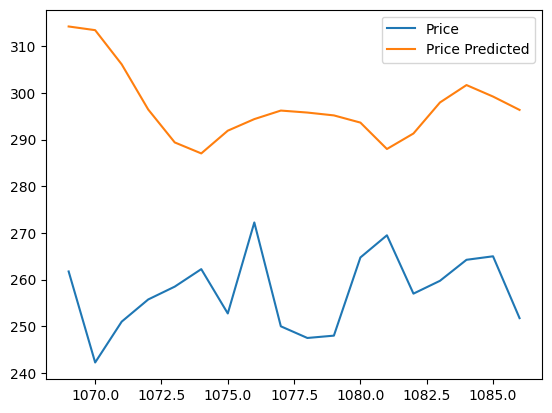

In [31]:
# Checking the prediction with the original price with the predicted price
data_final[['Price','Price Predicted']].plot()

In [32]:
!pip install dmba
from dmba import regressionSummary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
no display found. Using non-interactive Agg backend


In [33]:
regressionSummary(data_final.Price, data_final['Price Predicted'])


Regression statistics

                      Mean Error (ME) : -39.6891
       Root Mean Squared Error (RMSE) : 41.6247
            Mean Absolute Error (MAE) : 39.6891
          Mean Percentage Error (MPE) : -15.5571
Mean Absolute Percentage Error (MAPE) : 15.5571
